In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/luckyrao/financial-sample-data/04-01-Financial Sample Data.xlsx


Dataset link:- https://www.kaggle.com/datasets/luckyrao/financial-sample-data/data

In [2]:
data = pd.read_excel("/kaggle/input/datasets/luckyrao/financial-sample-data/04-01-Financial Sample Data.xlsx")

# 1. Data Understanding

In [3]:
df = pd.DataFrame(data)
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,CANADA,Carretera,NaN,1618.5,3.0,20.0,32370.0,0.0,32370.0,16185.0,16185.0,41640.0,1.0,January,2014.0
1,Government,germany,Carretera,NaN,1321.0,3.0,20.0,26420.0,0.0,26420.0,13210.0,13210.0,41640.0,1.0,January,2014.0
2,Midmarkets,FRANCE,Carretera,NaN,2178.0,3.0,15.0,32670.0,NaN,32670.0,21780.0,10890.0,41791.0,6.0,June,2014.0
3,Midmarket,Germany,Carretera,NaN,888.0,3.0,15.0,13320.0,0.0,13320.0,8880.0,4440.0,41791.0,6.0,June,2014.0
4,Midmarket,Mexico,Carretera,NaN,2470.0,3.0,15.0,37050.0,0.0,37050.0,24700.0,12350.0,41791.0,6.0,June,2014.0


With the help of above we find that:
* We need to fix `Units Sold` DataType
* `Month Number` and `month Name` are duplicate columns
* In `Date` columns Excel stores dates as the number of days since 1899-12-30 (with a historical quirk); It will fix in Data  Cleaning 

In [4]:
df["Discount Band"].unique()

array([nan, 'Low', 'Medium', 'High'], dtype=object)

In [5]:
df.shape

(711, 16)

In [6]:
df.duplicated().sum()

np.int64(10)

In [7]:
df.isna().sum()[df.isna().sum() > 0]

Segment                 7
Country                 7
Product                 7
Discount Band          62
Units Sold              7
Manufacturing Price     7
Sale Price              7
Gross Sales             7
Discounts              14
 Sales                  7
COGS                    7
Profit                  7
Date                    7
Month Number            7
Month Name              7
Year                    7
dtype: int64

Above shows that in every column there are null values

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 711 entries, 0 to 710
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Segment              704 non-null    object 
 1   Country              704 non-null    object 
 2   Product              704 non-null    object 
 3   Discount Band        649 non-null    object 
 4   Units Sold           704 non-null    float64
 5   Manufacturing Price  704 non-null    float64
 6   Sale Price           704 non-null    float64
 7   Gross Sales          704 non-null    float64
 8   Discounts            697 non-null    float64
 9    Sales               704 non-null    float64
 10  COGS                 704 non-null    float64
 11  Profit               704 non-null    float64
 12  Date                 704 non-null    float64
 13  Month Number         704 non-null    float64
 14  Month Name           704 non-null    object 
 15  Year                 704 non-null    flo

`Sales` column contains extra space

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Units Sold,704.0,1608.071023,866.645211,200.00,905.00,1542.50,2229.125,4492.5
Manufacturing Price,704.0,96.678977,108.755611,3.00,5.00,10.00,250.000,260.0
Sale Price,704.0,118.717330,136.950795,7.00,12.00,20.00,300.000,350.0
Gross Sales,704.0,183433.465199,254753.061586,1799.00,17391.75,37980.00,285225.000,1207500.0
Discounts,697.0,13223.783702,22988.722657,0.00,823.20,2661.75,16086.000,149677.5
Sales,704.0,170341.167983,237363.658900,1655.08,15928.00,35540.20,262618.125,1159200.0
COGS,704.0,145999.654830,204320.400008,918.00,7485.00,22506.25,246812.500,950625.0
Profit,704.0,24341.513153,42898.909023,-40617.50,2881.78,9242.60,22719.750,262200.0
Date,704.0,41757.742898,147.243156,41518.00,41632.25,41760.00,41890.500,41974.0
Month Number,704.0,7.894886,3.379762,1.00,5.00,9.00,10.250,12.0


* `Discounts` column contains redundant value
* `Date` and `Year` DataTypes needs to be fix

In [10]:
negative_profit = df[df['Profit'] < 0]
len(negative_profit)

58

#### Checking Spelling

In [11]:
cat_cols = df.select_dtypes(include='object').columns
print(len(cat_cols))

5


In [12]:
for col in cat_cols:
    print(f"\n{col}")
    print("Unique values are : ",df[col].unique())
    print("Unique values count : ",df[col].nunique())


Segment
Unique values are :  ['Government' 'Midmarkets' 'Midmarket' nan 'Channel Partners' 'Enterprise'
 'Small Business']
Unique values count :  6

Country
Unique values are :  ['CANADA' '   germany   ' 'FRANCE' 'Germany' '                  Mexico'
 nan 'GERMANY' '  Canada' '    France' 'germany' 'Mexico' 'Canada'
 ' mexico' 'United States \nof America' 'MEXICO' '   Canada' 'France'
 'United States of America']
Unique values count :  17

Product
Unique values are :  ['Carretera' nan 'Montana' 'Paseo' 'Velo' 'VTT' 'Amarilla']
Unique values count :  6

Discount Band
Unique values are :  [nan 'Low' 'Medium' 'High']
Unique values count :  3

Month Name
Unique values are :  ['January' 'June' nan 'December' 'March' 'July' 'August' 'September'
 'October' 'February' 'November' 'April' 'May']
Unique values count :  12


# 2. Data Cleaning

## 2.1 Fixing Additional Space in Column name

In [13]:
df = df.rename(columns={' Sales' : 'Sales'})
df['Sales'].sample(2)

592    299171.25
655     22931.04
Name: Sales, dtype: float64

## 2.2 Standardizing Inconsistent Category Names in the `Segment` Column

In [14]:
df['Segment'] = df['Segment'].replace({
    'Midmarkets': 'Midmarket'
})

## 2.3 Remove leading/trailing spaces from `Country` column values

In [15]:
df["Country"] = df["Country"].str.strip()
print("Total unique values : ",df["Country"].nunique())
df["Country"].unique()

Total unique values :  12


array(['CANADA', 'germany', 'FRANCE', 'Germany', 'Mexico', nan, 'GERMANY',
       'Canada', 'France', 'mexico', 'United States \nof America',
       'MEXICO', 'United States of America'], dtype=object)

In [16]:
df['Country'] = df['Country'] .replace({
        'United States \nof America': 'United States of America'
})

In [17]:
df["Country"].unique()

array(['CANADA', 'germany', 'FRANCE', 'Germany', 'Mexico', nan, 'GERMANY',
       'Canada', 'France', 'mexico', 'United States of America', 'MEXICO'],
      dtype=object)

## 2.4 Removing Duplicates

In [18]:
df = df.drop_duplicates()
df.shape

(701, 16)

## 2.5 Standardize text in categorical/object columns

In [19]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns

In [20]:
for col in cat_cols:
    df[col] = df[col].str.strip().str.lower()

In [21]:
for col in cat_cols:
    print(f"\n{col}")
    print("Unique values are : ",df[col].unique())
    print("Unique values count : ",df[col].nunique())


Segment
Unique values are :  ['government' 'midmarket' nan 'channel partners' 'enterprise'
 'small business']
Unique values count :  5

Country
Unique values are :  ['canada' 'germany' 'france' 'mexico' nan 'united states of america']
Unique values count :  5

Product
Unique values are :  ['carretera' nan 'montana' 'paseo' 'velo' 'vtt' 'amarilla']
Unique values count :  6

Discount Band
Unique values are :  [nan 'low' 'medium' 'high']
Unique values count :  3

Month Name
Unique values are :  ['january' 'june' nan 'december' 'march' 'july' 'august' 'september'
 'october' 'february' 'november' 'april' 'may']
Unique values count :  12


## 2.6 Filling missing values

In [22]:
# Fill NaN values in categorical columns with mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Fill NaN values in numerical columns with median
num_cols = df.select_dtypes(include=["number"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [23]:
print("Total null vlaues : ",df.isna().sum()[df.isna().sum() > 0])

Total null vlaues :  Series([], dtype: int64)


## 2.7 Fixing Excel Date to Acual Dates

In [24]:
df['Date'] = pd.to_datetime(df['Date'], unit='D', origin='1899-12-30')

# 3. EDA

In [25]:
# Total Numerical Columns
print(f"Total Numerical Columns: {len(num_cols)}")

# Total Categorical Columns
print(f"Total Categorical Columns: {len(cat_cols)}")

Total Numerical Columns: 11
Total Categorical Columns: 5


## 3.1 Univariate Analysis

### 3.1.1 Numerical Columns

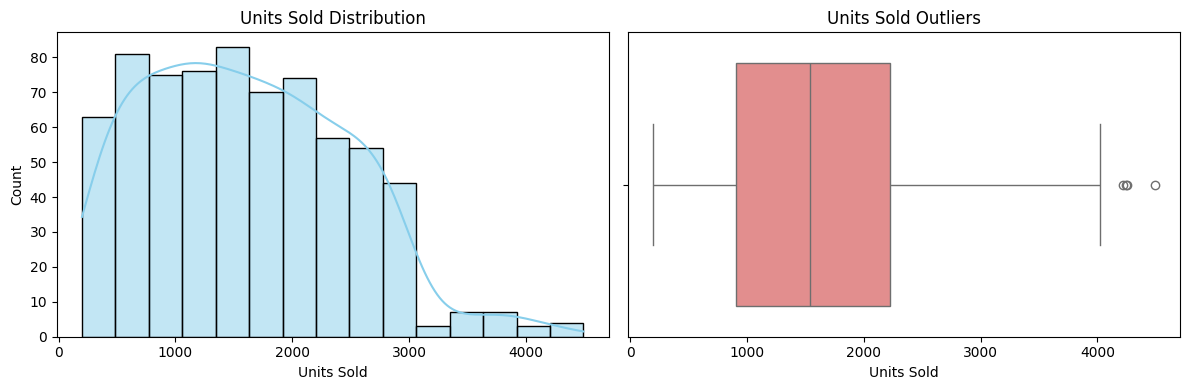

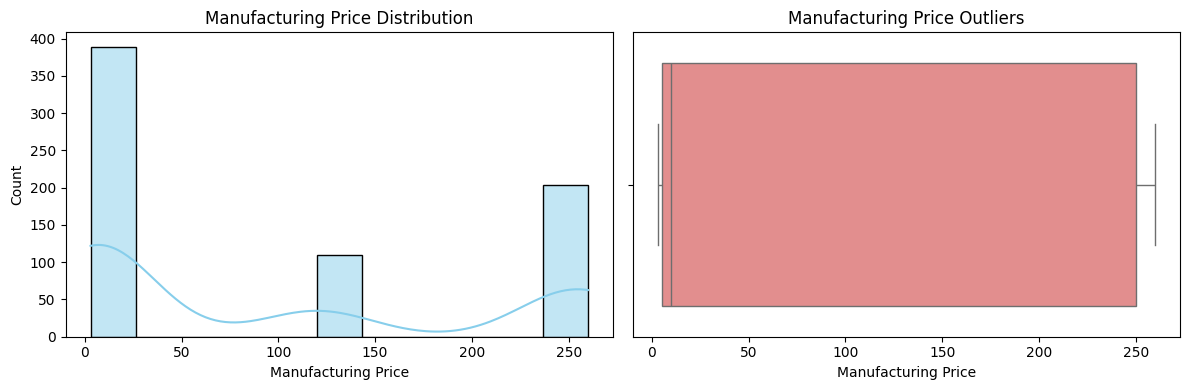

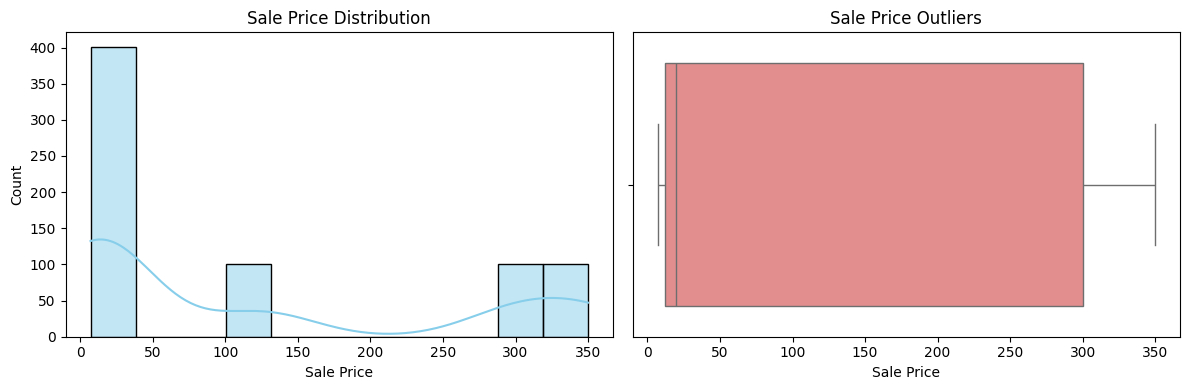

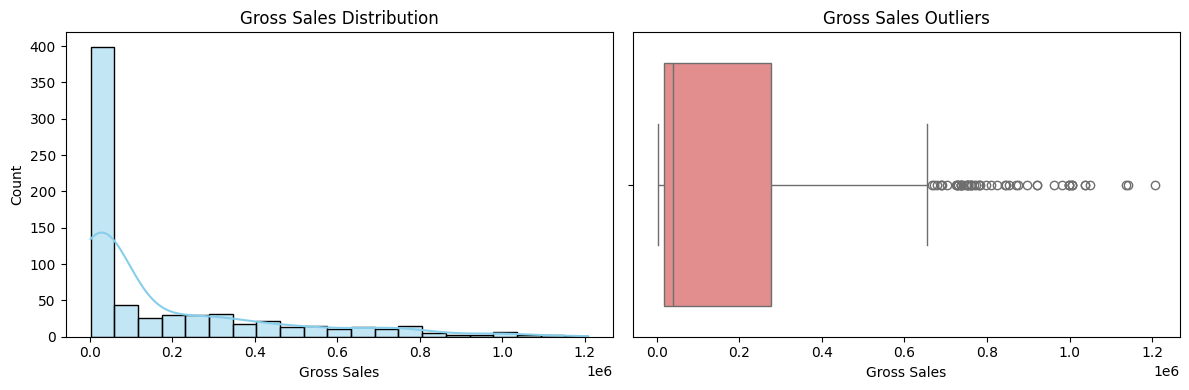

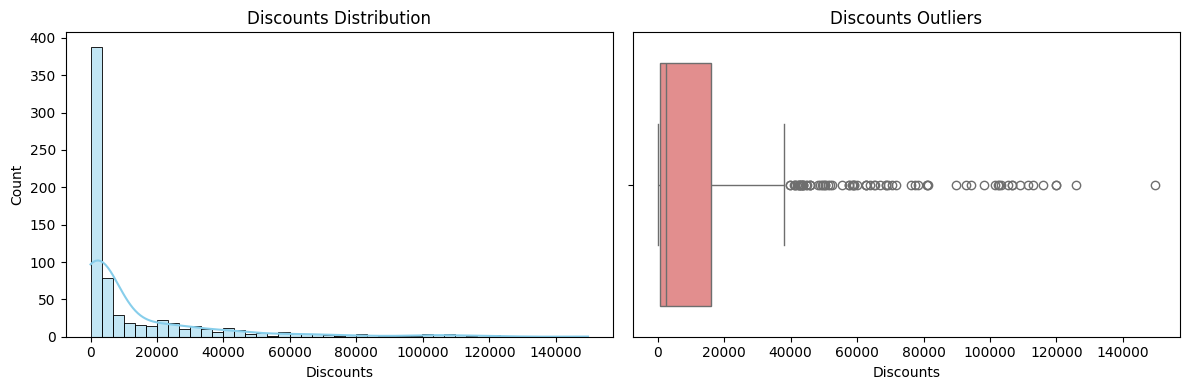

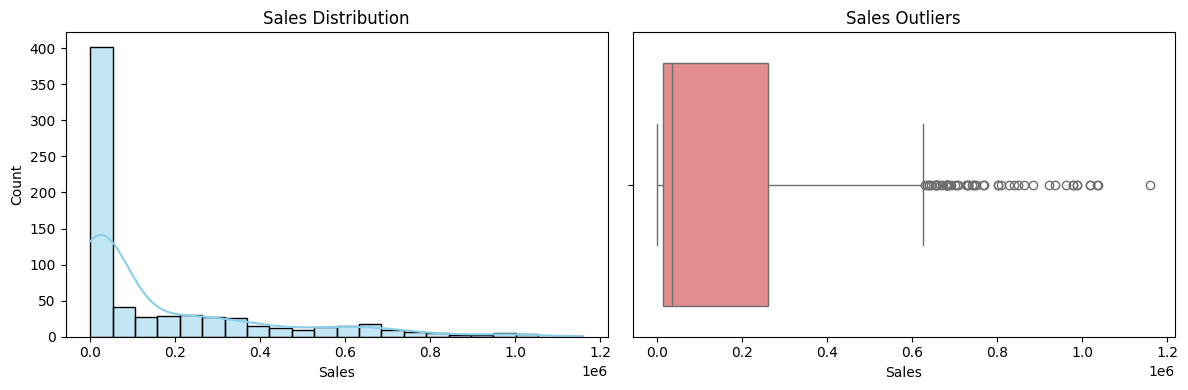

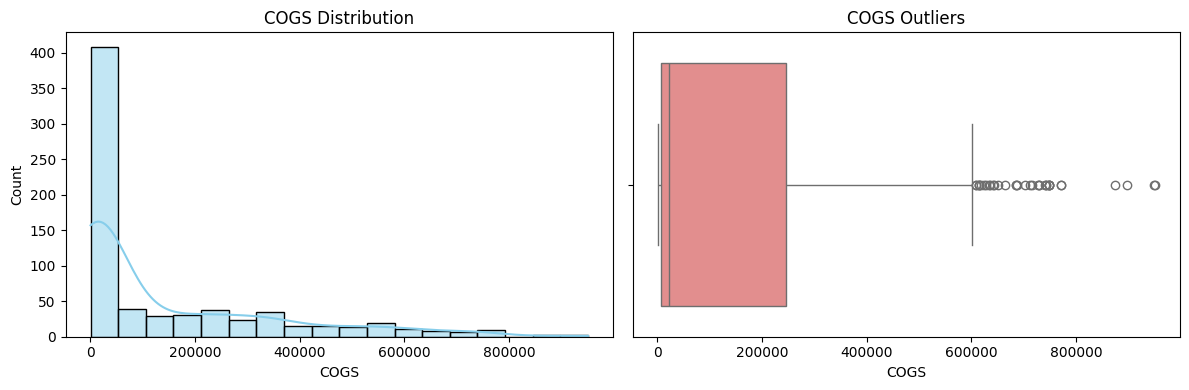

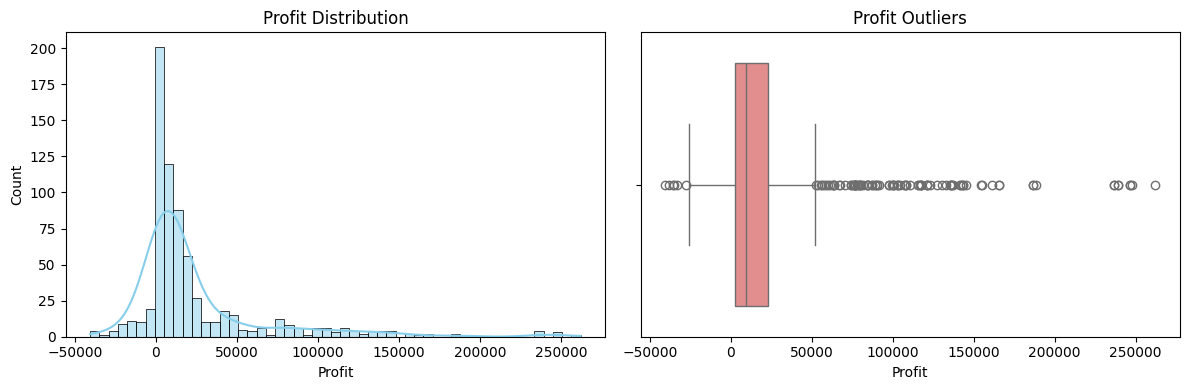

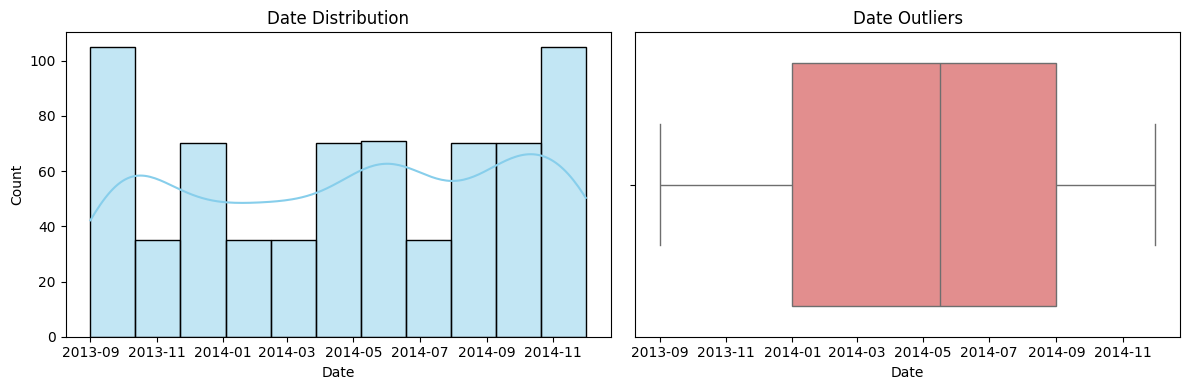

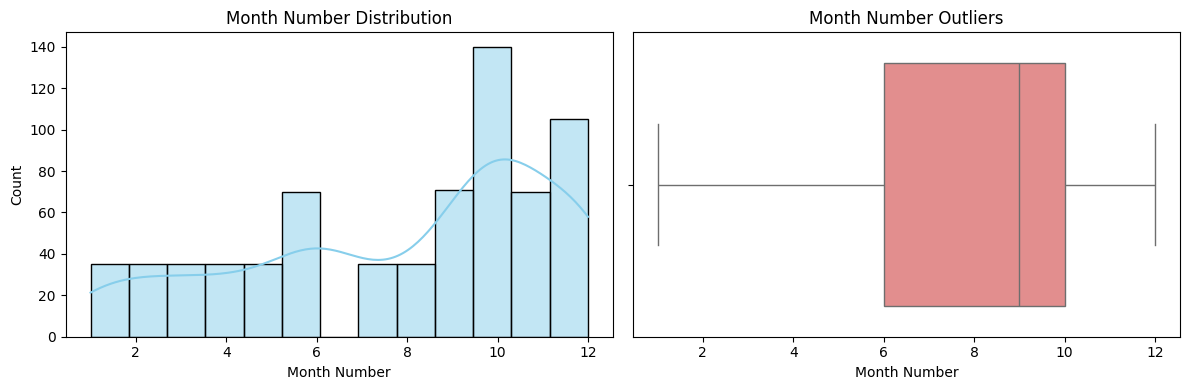

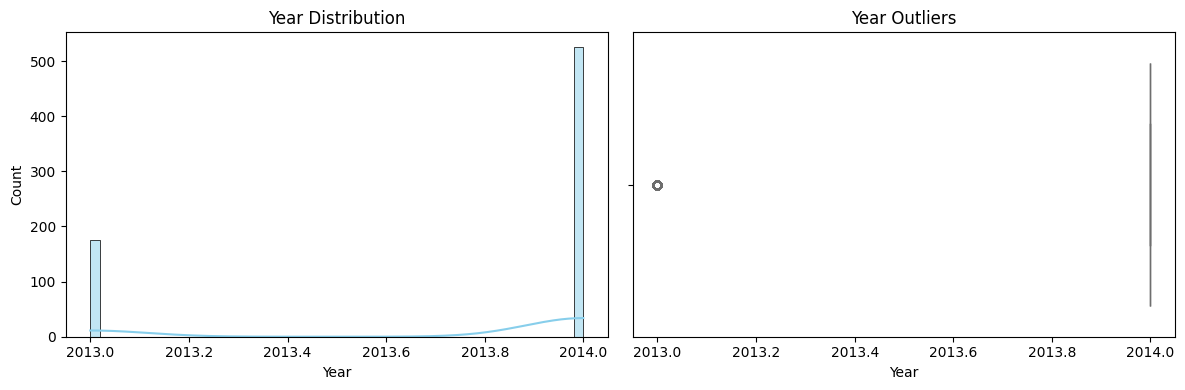

In [26]:
# Plot Histograms and Boxplots side-by-side for each numerical column
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram with KDE curve
    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'{col} Distribution')
    
    # Boxplot for outliers
    sns.boxplot(data=df, x=col, ax=axes[1], color='lightcoral')
    axes[1].set_title(f'{col} Outliers')
    
    plt.tight_layout()
    plt.show()

### 3.1.2 Categorical Columns (Count plots)

In [27]:
import math

def count_plot(cols):
    n = len(cols)
    rows = math.ceil(n / 2)

    plt.figure(figsize=(14, 5 * rows))

    for i, col in enumerate(cols, 1):
        plt.subplot(rows, 2, i)

        sns.countplot(
            data=df,
            x=col,
            order=df[col].value_counts().index,
            legend=True
        )

        plt.title(f'{col} Frequency')
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

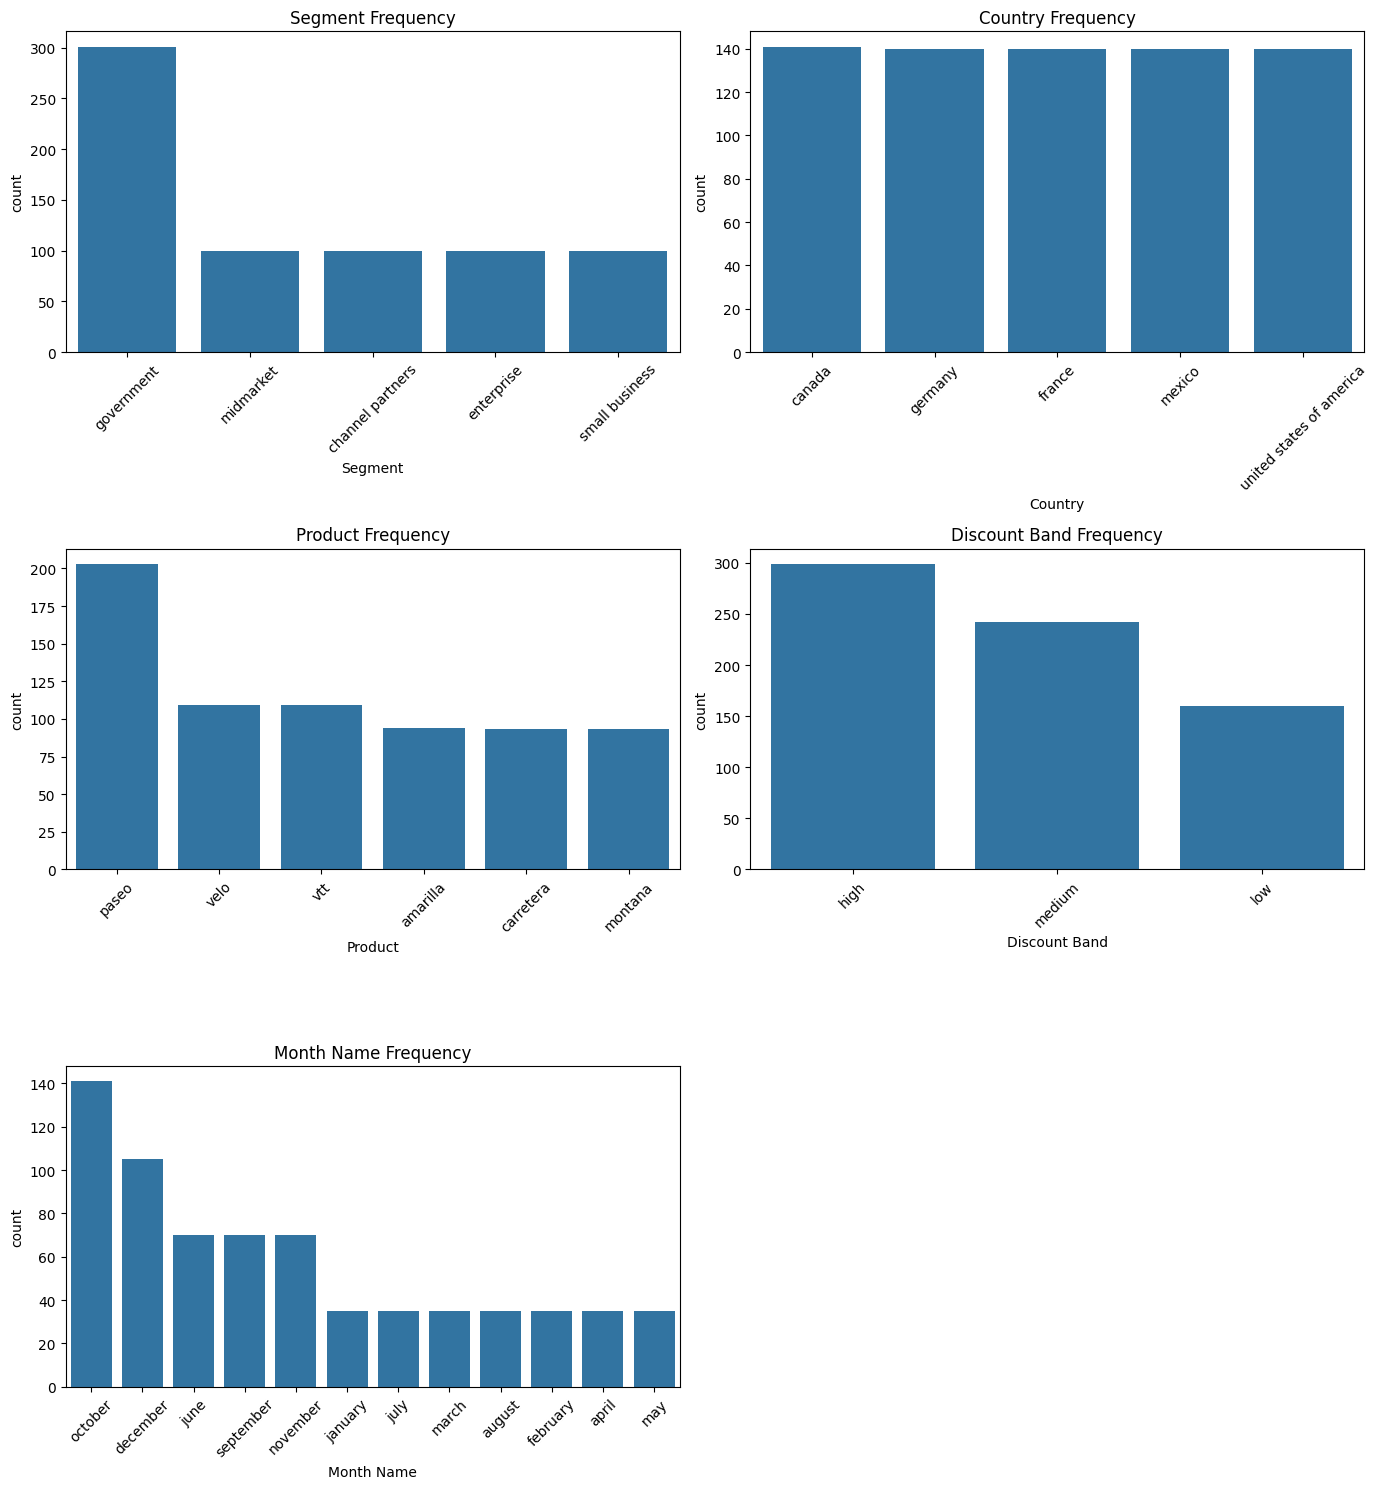

In [28]:
count_plot(cat_cols)

## 3.2 Bivariate Analysis

### 3.2.1 Numerical vs Numerical

#### Heatmap

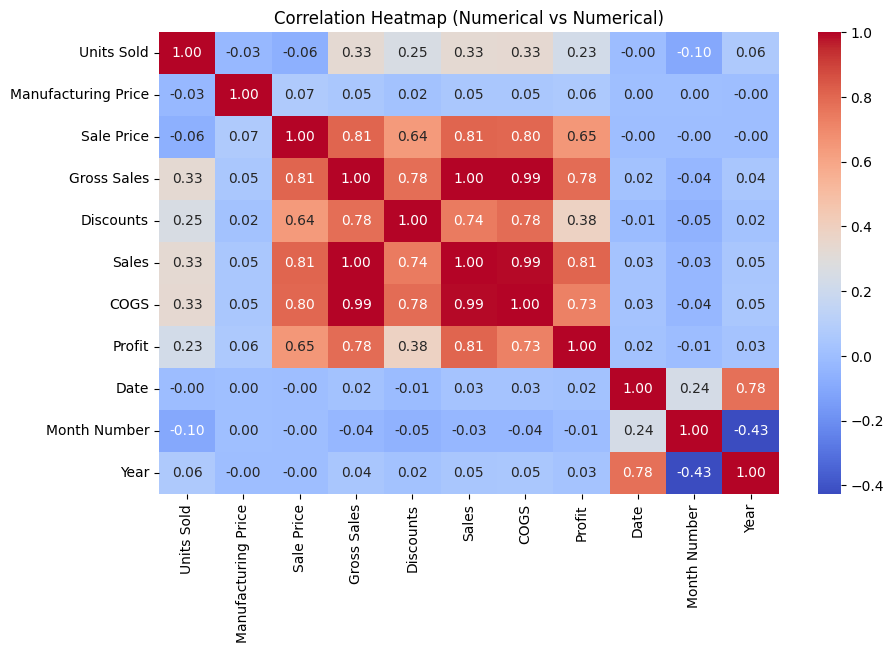

In [29]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Numerical vs Numerical)")
plt.show()

#### Scatterplot

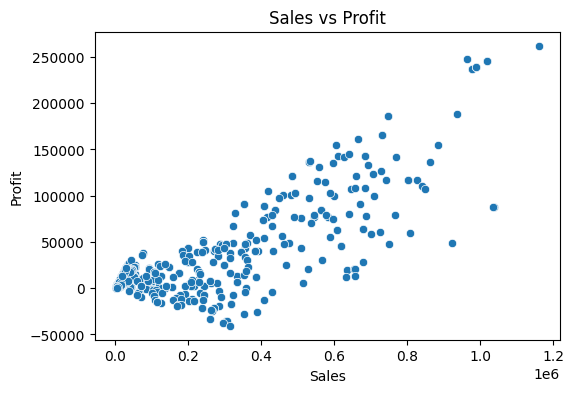

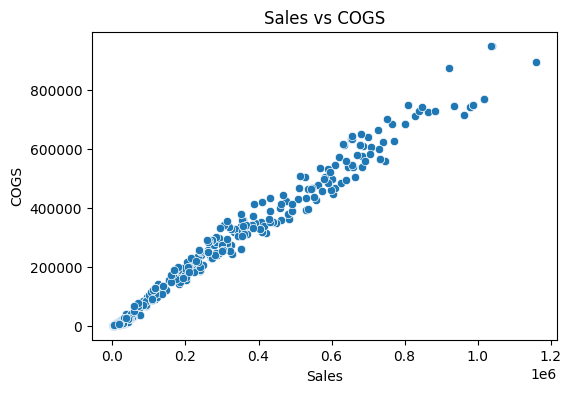

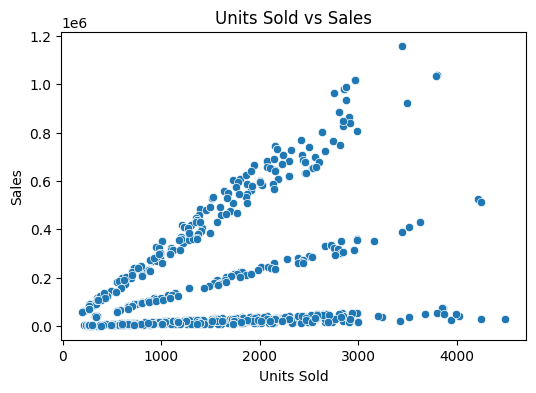

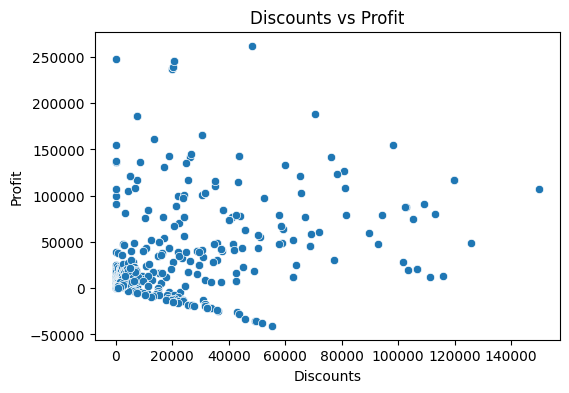

In [30]:
pairs = [('Sales', 'Profit'),
         ('Sales', 'COGS'),
         ('Units Sold', 'Sales'),
         ('Discounts', 'Profit')]

for x, y in pairs:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=x, y=y)
    plt.title(f"{x} vs {y}")
    plt.show()

#### Regerssion plot

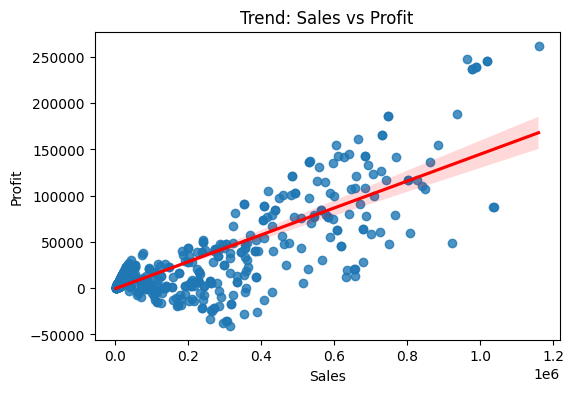

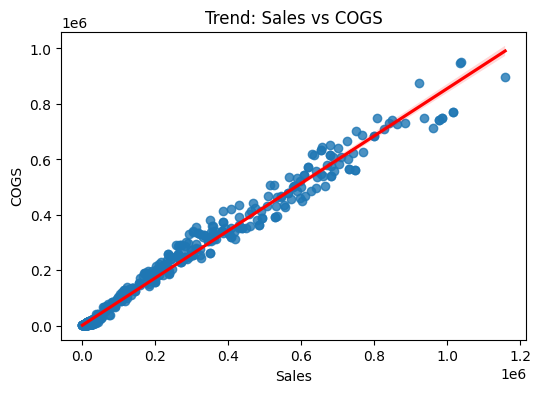

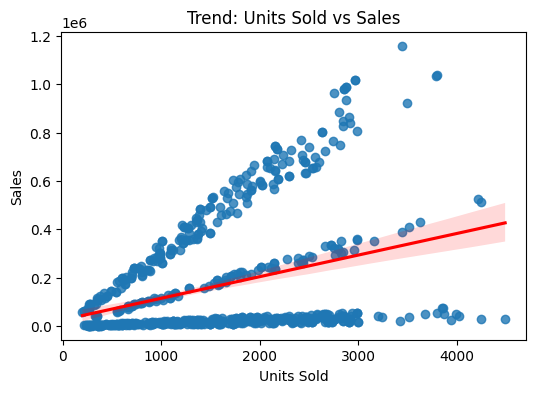

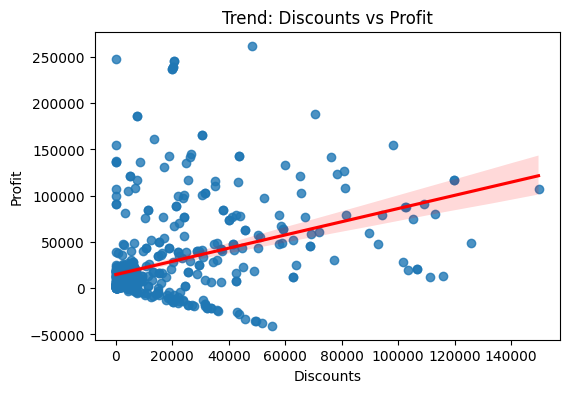

In [31]:
for x, y in pairs:
    plt.figure(figsize=(6,4))
    sns.regplot(data=df, x=x, y=y, line_kws={"color":"red"})
    plt.title(f"Trend: {x} vs {y}")
    plt.show()

### 3.2.2 Categorical vs Categorical

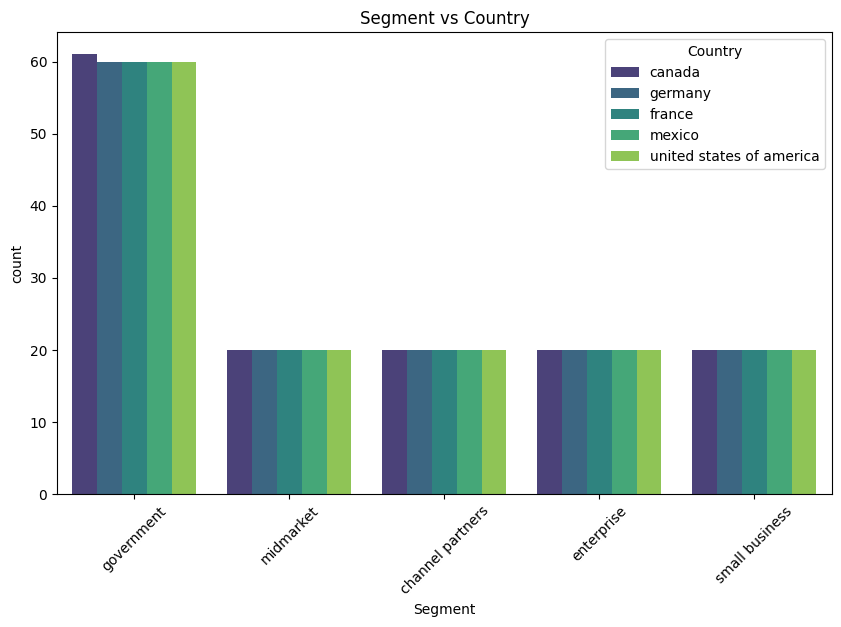

In [32]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='Segment',
    hue='Country',
    palette='viridis'
)

plt.title("Segment vs Country")
plt.xticks(rotation=45)
plt.show()

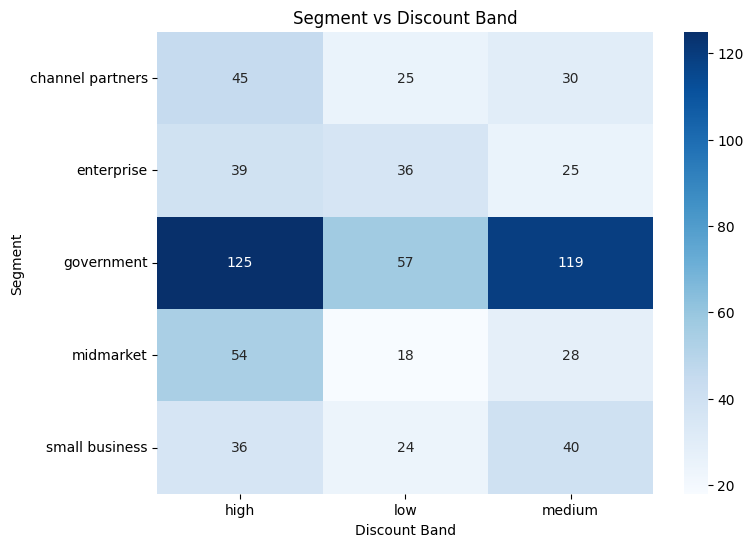

In [33]:
cross_tab = pd.crosstab(
    df['Segment'],
    df['Discount Band']
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cross_tab,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Segment vs Discount Band")
plt.show()

### 3.2.3 Numerical vs Categorical

#### Boxplot

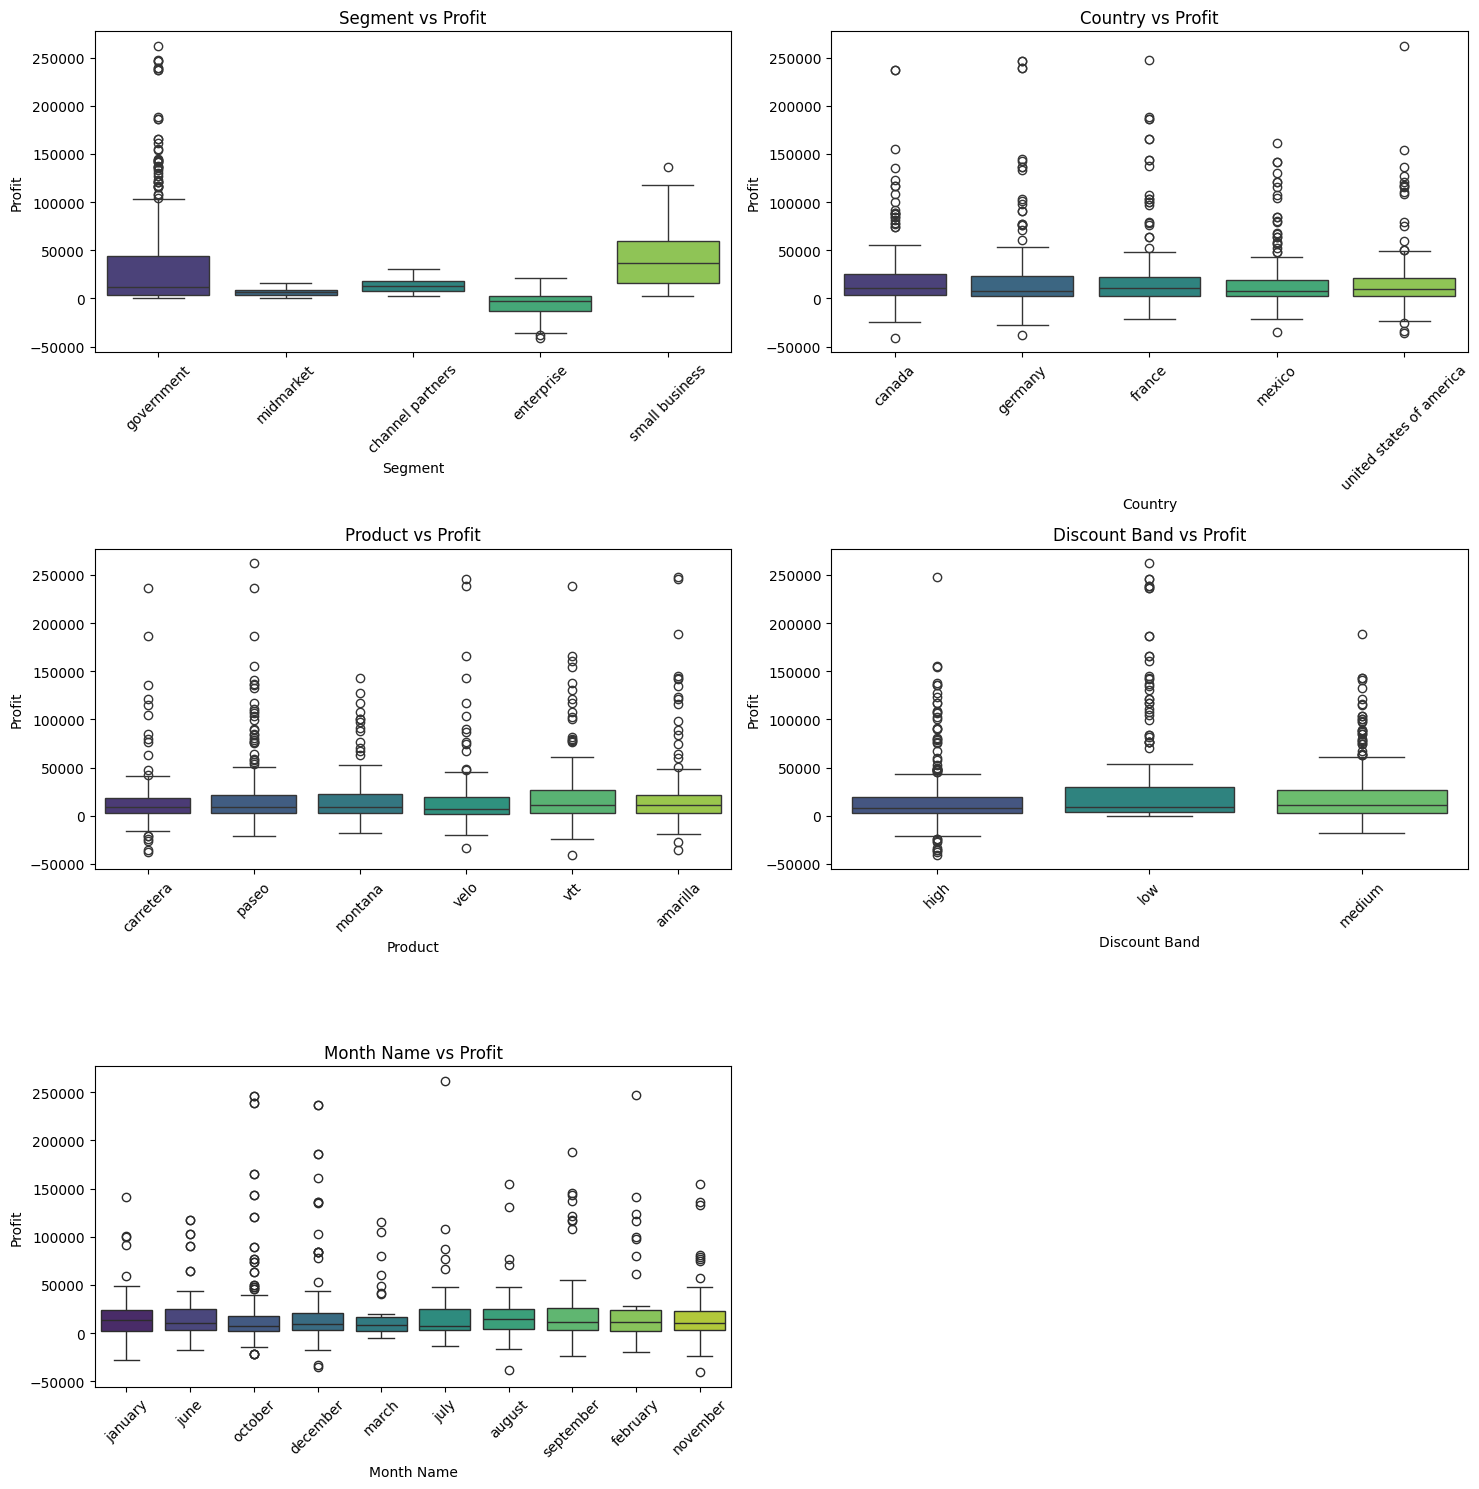

In [34]:
import math

def box_plot(cols, target):
    n = len(cols)
    rows = math.ceil(n / 2)

    plt.figure(figsize=(15, 5 * rows))

    for i, col in enumerate(cols, 1):
        plt.subplot(rows, 2, i)

        top = df[col].value_counts().head(10).index

        sns.boxplot(
            data=df[df[col].isin(top)],
            x=col,
            y=target,
            hue=col,
            palette='viridis',
            legend=False
        )

        plt.title(f"{col} vs {target}")
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

box_plot(cat_cols, 'Profit')

#### Bar Plot

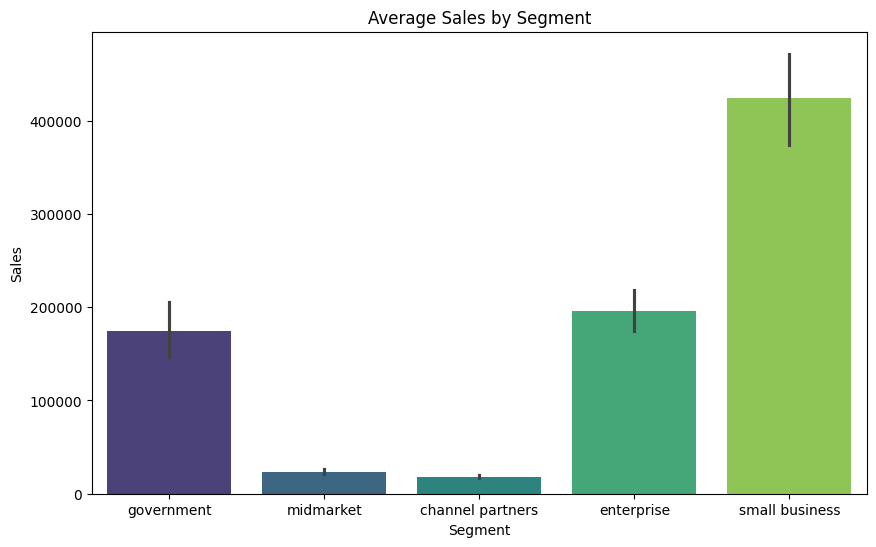

In [35]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='Segment',
    y='Sales',
    hue='Segment',
    estimator='mean',
    palette='viridis',
    legend=False
)

plt.title("Average Sales by Segment")
plt.show()

## 3.3 Multivariate Analysis

#### Pair Plot

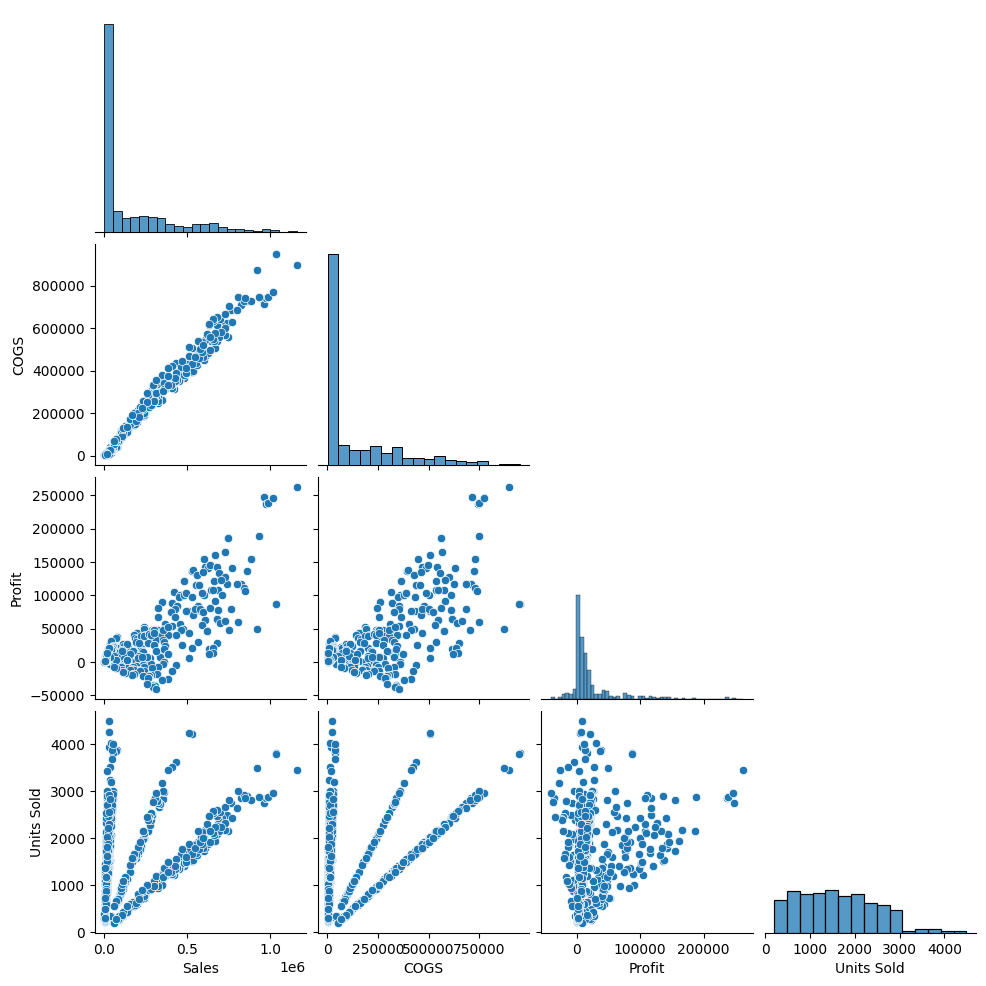

In [36]:
cols = ['Sales', 'COGS', 'Profit', 'Units Sold']

sns.pairplot(df[cols], corner=True)
plt.show()

#### Scatter Plot with hue

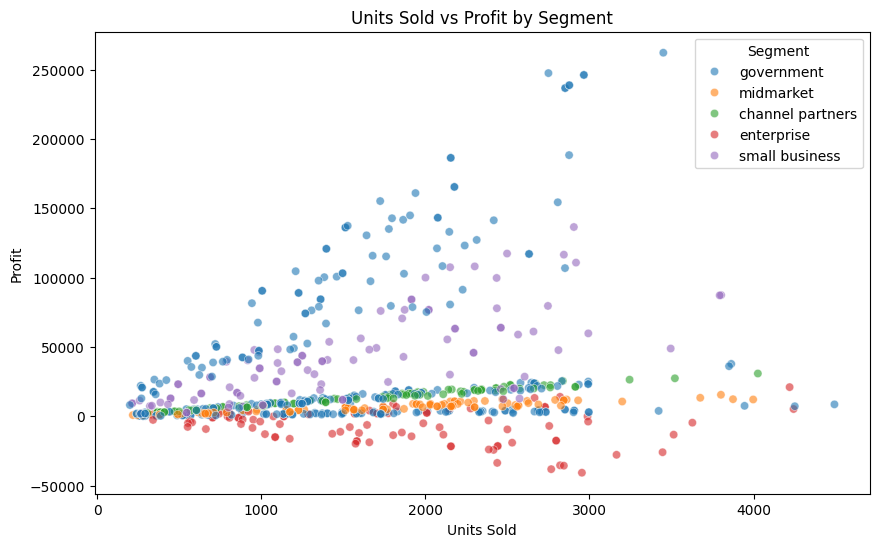

In [37]:
# Modified Version (Units Sold vs Profit by Segment)
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Units Sold',
    y='Profit',
    hue='Segment',
    alpha=0.6
)

plt.title("Units Sold vs Profit by Segment")
plt.show()

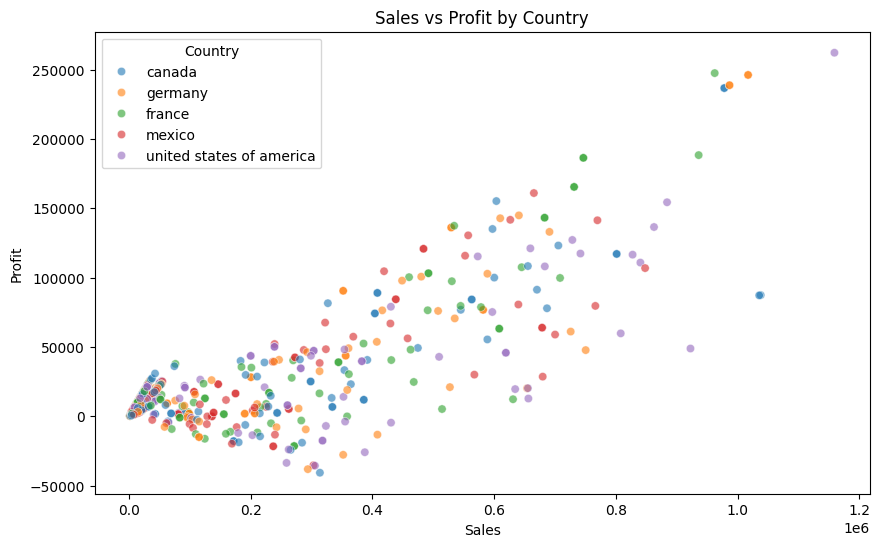

In [38]:
# Sales vs Profit by Country
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit',
    hue='Country',
    alpha=0.6
)

plt.title("Sales vs Profit by Country")
plt.show()

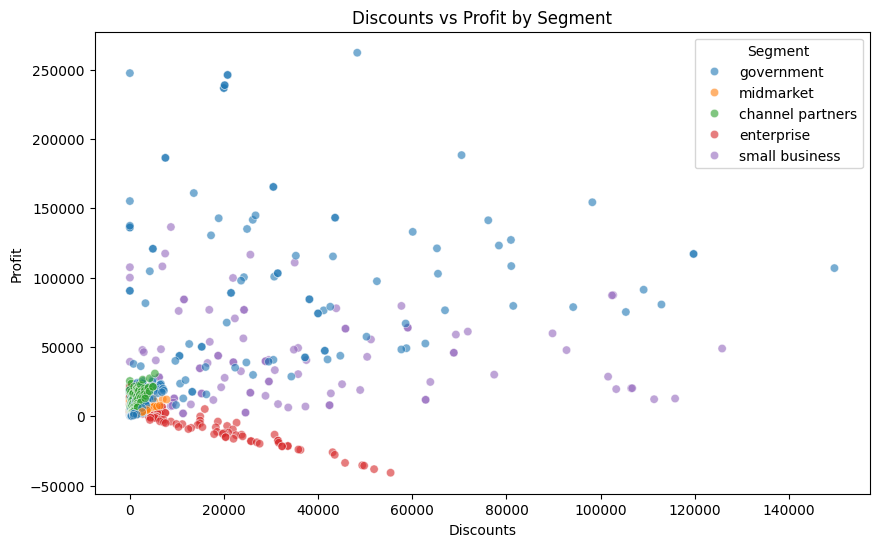

In [39]:
# Discount impact 
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Discounts',
    y='Profit',
    hue='Segment',
    alpha=0.6
)

plt.title("Discounts vs Profit by Segment")
plt.show()

# 4. Feature Transformation

In [40]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split

In [41]:
from scipy import stats
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
z_scores = np.abs(stats.zscore(df[num_cols], nan_policy='omit'))
outliers = (z_scores > 3).sum()
print(outliers)

72


## 4.1 Quantile Range(for a few outliers)

In [42]:
Q1 = df['Units Sold'].quantile(0.25)
Q3 = df['Units Sold'].quantile(0.75)
IQR = Q3 - Q1

df['Units Sold'] = df['Units Sold'].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

## 4.2 Log Transformation

In [43]:
# Gross Sales -> Highly right-skewed; Strong outliers
df['Gross Sales'] = np.log1p(df['Gross Sales'])
# Discounts -> Extremely skewed;Many zeros or very small values;Huge outliers exist
df['Discounts'] = np.log1p(df['Discounts'])
# Sales -> Very skewed (like Gross Sales); Outliers present
df['Sales'] = np.log1p(df['Sales'])
# COGS -> Same pattern as Sales;Heavy right skew
df['COGS'] = np.log1p(df['COGS'])

In [44]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
z_scores = np.abs(stats.zscore(df[num_cols], nan_policy='omit'))
outliers = (z_scores > 3).sum()
print(outliers)

20


## 4.3 Extracting Meaningful Features from `Date`

In [45]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.dayofweek

In [46]:
# Dropping raw date
df.drop('Date', axis=1, inplace=True)

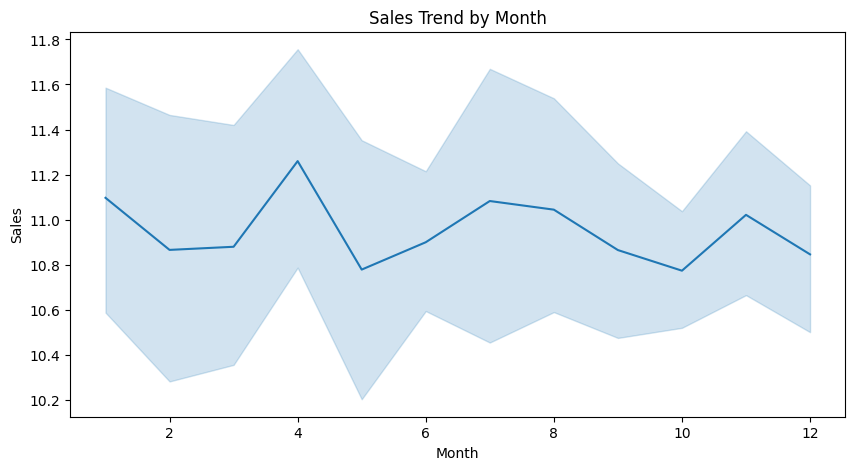

In [47]:
# Sales over time
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='Month', y='Sales')
plt.title("Sales Trend by Month")
plt.show()

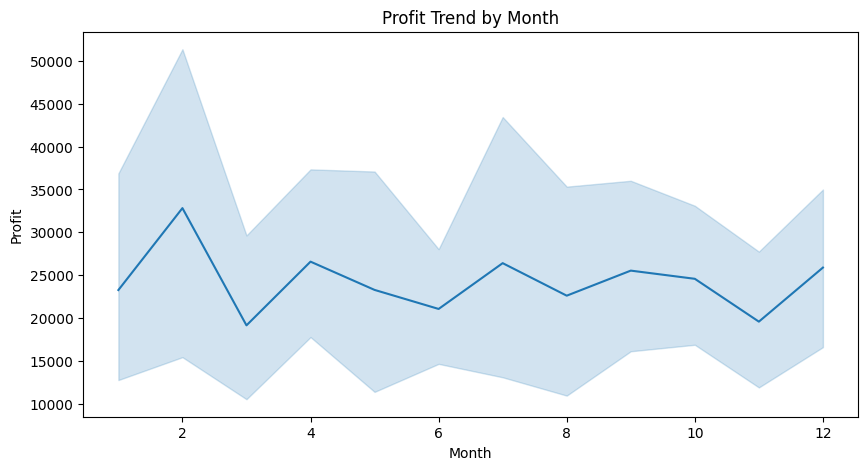

In [48]:
# Profit over time
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='Month', y='Profit')
plt.title("Profit Trend by Month")
plt.show()

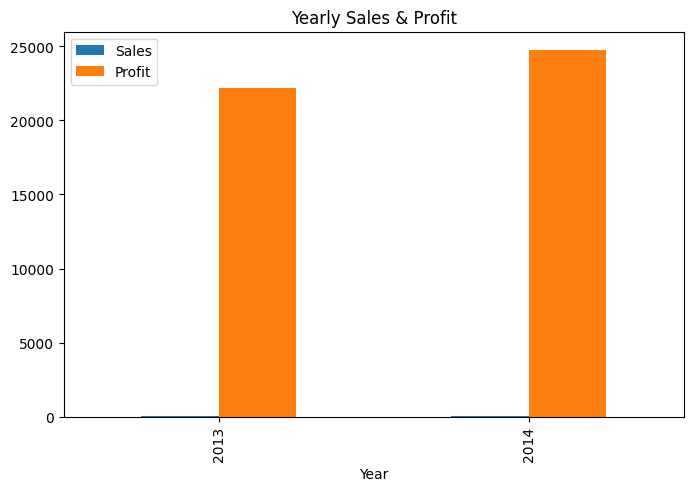

In [49]:
# Yearly performance
df.groupby('Year', observed=False)[['Sales', 'Profit']].mean().plot(kind='bar', figsize=(8,5))
plt.title("Yearly Sales & Profit")
plt.show()

In [50]:
# Time should be treated as categorical, not continuous numbers
df['Month'] = df['Month'].astype('category')
df['Weekday'] = df['Weekday'].astype('category')
df['Year'] = df['Year'].astype('category')

In [51]:
df[['Year', 'Month', 'Day', 'Weekday']].head()

,Year,Month,Day,Weekday
0,2014,1,1,2
1,2014,1,1,2
2,2014,6,1,6
3,2014,6,1,6
4,2014,6,1,6


## 4.4 One-Hot Encoding

In [52]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

#### Splitting Data before Feature scaling

In [53]:
X = df.drop('Profit', axis=1)
y = df['Profit']

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## 4.5 Standard Scaling

In [55]:
# Implement StandardScaler to eliminate scaling bias across numerical features.

all_numeric_cols  = X_train.select_dtypes(include='number').columns # keep only non-binary numeric columns and scale them

cols_to_scale  = [c for c in all_numeric_cols  if df[c].nunique() > 2]

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transform ONLY if using fit_transform so X_test uses it's own mean value
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [56]:
X_train = pd.DataFrame(X_train)
X_train.head(2)

,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Month Number,Day,Segment_enterprise,...,Month_9,Month_10,Month_11,Month_12,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
175,0.132752,-0.795863,0.096661,0.830760,0.411132,0.85909,0.962756,1.198207,1,True,...,False,False,False,True,False,False,False,False,False,False
552,0.211442,-0.841991,1.397514,1.390688,1.275228,1.35863,1.374006,-1.167578,1,False,...,False,False,False,False,True,False,False,False,False,False


In [57]:
df.shape

(701, 54)

# 5. Machine Learning and Hyperparameter Tuning

In [58]:
from sklearn.model_selection import RandomizedSearchCV,KFold, cross_val_score

# Linear Models
from sklearn.linear_model import LinearRegression

# Tree-Based Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Boosting Models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [59]:
models = {

    # ============================
    # Linear Models (Baseline)
    # ============================
    "Linear Regression": LinearRegression(
        n_jobs=-1  # if supported by your sklearn version
    ),

    # ============================
    # Tree-Based Models
    # ============================
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    # ============================
    # Boosting Models (CPU)
    # ============================
    "XGBoost": XGBRegressor(
        random_state=42,
        objective='reg:squarederror',
        tree_method='hist'  # CPU-optimized
    ),

    "LightGBM": LGBMRegressor(
        random_state=42,
        force_col_wise=True,
        verbose=-1
    )
}

In [60]:
param_grids = {
    "Linear Regression": {},

    "Decision Tree": {
        "max_depth": [3, 5, 7, 10, 15, None],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 5, 10],
        "criterion": ["squared_error", "friedman_mse"]
    },

    "XGBoost": {
        "n_estimators": [100, 200, 300, 500],
        "max_depth": [3, 4, 5, 6, 7],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "subsample": [0.6, 0.7, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
        "gamma": [0, 0.1, 0.2]
    },

    "LightGBM": {
        "n_estimators": [100, 200, 300, 500],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "num_leaves": [15, 31, 50, 70],
        "max_depth": [-1, 3, 5, 7, 10],
        "min_child_samples": [5, 10, 20, 30],
        "subsample": [0.7, 0.8, 1.0],
        "colsample_bytree": [0.7, 0.8, 1.0]
    }
}

In [61]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [62]:
best_model = None
best_score = -float("inf")
best_model_name = ""

results = {}

for name, model in models.items():
    
    print(f"\nRunning GridSearchCV for {name}...")
    
    random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grids[name],
    cv=kf,
    scoring='r2',
    n_jobs=1,
    n_iter=20 if model == "LightGBM" else 50,
    random_state=42
    )

    random_search.fit(X_train, y_train)

    results[name] = {
        "Best Params": random_search.best_params_,
        "Best CV Score (R2)": random_search.best_score_
    }

    print(name)
    print("Best Params:", random_search.best_params_)
    print("Best CV Score (R2):", random_search.best_score_)

    # STORE ONLY BEST MODEL
    if random_search.best_score_ > best_score:
        best_score = random_search.best_score_
        best_model = random_search.best_estimator_
        best_model_name = name


Running GridSearchCV for Linear Regression...
Linear Regression
Best Params: {}
Best CV Score (R2): 0.7229427186134604

Running GridSearchCV for Decision Tree...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=50. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Decision Tree
Best Params: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 15, 'criterion': 'squared_error'}
Best CV Score (R2): 0.9489361287180197

Running GridSearchCV for XGBoost...
XGBoost
Best Params: {'subsample': 0.6, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best CV Score (R2): 0.9757644951005938

Running GridSearchCV for LightGBM...
LightGBM
Best Params: {'subsample': 0.8, 'num_leaves': 15, 'n_estimators': 500, 'min_child_samples': 5, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV Score (R2): 0.9759833066198802


In [63]:
# DataFram of results to make it more readable
results_df = pd.DataFrame(results).T
results_df.sort_values(by="Best CV Score (R2)", ascending=False)

,Best Params,Best CV Score (R2)
LightGBM,"{'subsample': 0.8, 'num_leaves': 15, 'n_estima...",0.975983
XGBoost,"{'subsample': 0.6, 'n_estimators': 300, 'max_d...",0.975764
Decision Tree,"{'min_samples_split': 5, 'min_samples_leaf': 1...",0.948936
Linear Regression,{},0.722943


In [64]:
print("Best Model:", best_model_name)
print("Best CV Score (R2):", best_score)

Best Model: LightGBM
Best CV Score (R2): 0.9759833066198802


In [65]:
y_pred = best_model.predict(X_test)

In [66]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 3493.3142826773037
RMSE: 7516.967001942295
R2 Score: 0.9662245515708459
